In [5]:
def plot2d(im, ax=None, colorbar=True, show=True, **kwargs):
    """
    Display the spectrogram of an audio signal. 
    
    The spectrogram should be previously computed using the function 
    ``maad.sound.spectrogram``.
    
    Parameters
    ----------
    im : 2D numpy array 
        Image or Spectrogram
        
    ax : axis, optional, default is None
        Draw the image on this specific axis. Allow multiple plots on the same
        figure.
            
    kwargs, optional
        - figsize : tuple of integers, optional, default: (4,13)
            width, height in inches.  
        - title : string, optional, default : 'Spectrogram'
            title of the figure
        - xlabel : string, optional, default : 'Time [s]'
            label of the horizontal axis
        - ylabel : string, optional, default : 'Frequency [Hz]'
            label of the vertical axis
        - xticks : tuple of ndarrays, optional, default : none
            * ticks : array_like => A list of positions at which ticks should be placed. You can pass an empty list to disable yticks.
            * labels : array_like, optional =>  A list of explicit labels to place at the given locs.
        - yticks : tuple of ndarrays, optional, default : none
            * ticks : array_like => A list of positions at which ticks should be placed. You can pass an empty list to disable yticks.
            * labels : array_like, optional =>  A list of explicit labels to place at the given locs.
        - cmap : string or Colormap object, optional, default is 'gray'
            See https://matplotlib.org/examples/color/colormaps_reference.html
            in order to get all the  existing colormaps
            examples: 'hsv', 'hot', 'bone', 'tab20c', 'jet', 'seismic', 
            'viridis'...
        - vmin, vmax : scalar, optional, default: None
            `vmin` and `vmax` are used in conjunction with norm to normalize
            luminance data.  Note if you pass a `norm` instance, your
            settings for `vmin` and `vmax` will be ignored.
        - extent : list of scalars [left, right, bottom, top], optional, default: None
            The location, in data-coordinates, of the lower-left and
            upper-right corners. If `None`, the image is positioned such that
            the pixel centers fall on zero-based (row, column) indices.
        - now : boolean, optional, default : True
            if True, display now. Cannot display multiple images. 
            To display mutliple images, set now=False until the last call for 
            the last image    
        - interpolation : list of string [None, 'none', 'nearest', 'bilinear', 
            'bicubic', 'spline16','spline36', 'hanning', 'hamming', 'hermite', 
            'kaiser', 'quadric','catrom', 'gaussian', 'bessel', 'mitchell', 
            'sinc', 'lanczos'], optional, default : None
            
        ... and more, see matplotlib
        
    Returns
    -------
    fig : Figure
        The Figure instance 
    ax : Axis
        The Axis instance
        
    Examples
    --------
    >>> w, fs = maad.sound.load('../data/cold_forest_daylight.wav') 
    >>> Sxx_power,tn,fn,_ = maad.sound.spectrogram(w,fs)
    >>> Lxx = maad.spl.power2dBSPL(Sxx_power, gain=42) # convert into dB SPL
    >>> fig_kwargs = {'vmax': Lxx.max(),
                    'vmin':0,
                    'extent':(tn[0], tn[-1], fn[0], fn[-1]),
                    'title':'Power spectrogram density (PSD) in dB SPL',
                    'xlabel':'Time [s]',
                    'ylabel':'Frequency [Hz]',
                    }
    >>> ax, fig = maad.util.plot2d(Lxx,interpolation=None,**fig_kwargs)      
        
    """

    # matplotlib parameters
    title = kwargs.pop("title", "")
    ylabel = kwargs.pop("ylabel", "Frequency [Hz]")
    xlabel = kwargs.pop("xlabel", "Time [s]")
    xticks = kwargs.pop("xticks", None)
    yticks = kwargs.pop("yticks", None)
    cmap = kwargs.pop("cmap", "gray")
    vmin = kwargs.pop("vmin", None)
    vmax = kwargs.pop("vmax", None)
    extent = kwargs.pop("extent", None)
    now = kwargs.pop("now", False)
    print(now)

    if extent is not None:
        figsize = kwargs.pop(
            "figsize",
            (0.20 * (extent[3] - extent[2]) / 1000, 0.33 * (extent[1] - extent[0])),
        )
    else:
        figsize = kwargs.pop("figsize", (4, 13))

    # if no ax, create a figure and a subplot associated a figure otherwise
    # find the figure that belongs to ax
    if ax is None:
        fig, ax = plt.subplots()
        # set the paramters of the figure
        fig.set_facecolor("w")
        fig.set_edgecolor("k")
        fig.set_figheight(figsize[0] + 1)
        fig.set_figwidth(figsize[1])
    else:
        fig = ax.get_figure()

    # display image
    _im = ax.imshow(im, extent=extent, origin="lower", cmap=cmap, 
                    vmin=vmin, vmax=vmax, **kwargs)
    if colorbar==True:
        plt.colorbar(_im, ax=ax)

    # set the parameters of the subplot
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if xticks is not None:
        ax.set_xticks(ticks=xticks[0])
        if len(xticks) == 2:
            ax.set_xticklabels(labels=xticks[1])
    if yticks is not None:
        ax.set_yticks(ticks=yticks[0])
        if len(yticks) == 2:
            ax.set_yticklabels(labels=yticks[1])
    ax.axis("tight")

    fig.tight_layout()

    # Display the figure now
    if now:
        plt.show()
    
    if not show:
      plt.close(fig)

    return ax, fig

True


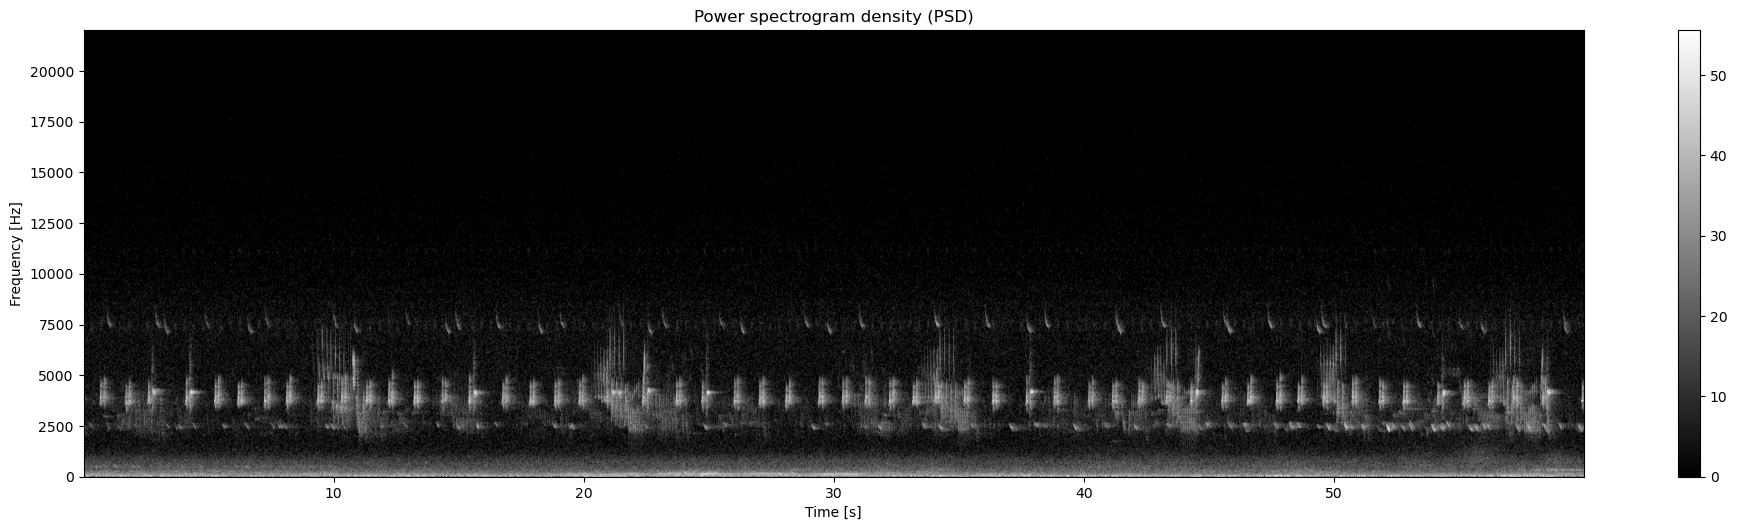

False


In [7]:
import matplotlib.pyplot as plt
from maad import sound, util, spl

w, fs = sound.load('data/cold_forest_daylight.wav') 

Sxx_power,tn,fn,_ = sound.spectrogram(w,fs)

Lxx = spl.power2dBSPL(Sxx_power, gain=42) # convert into dB SPL

fig_kwargs = {'vmax': Lxx.max(),
                'vmin':0,
                'extent':(tn[0], tn[-1], fn[0], fn[-1]),
                'title':'Power spectrogram density (PSD)',
                'xlabel':'Time [s]',
                'ylabel':'Frequency [Hz]',
                'now': True,
                }

fig, ax = plot2d(Lxx, show=True, **fig_kwargs)      

Lxx_crop, tn_crop, fn_crop = util.crop_image(Lxx, tn, fn, fcrop=(2000,10000), tcrop=(0,30))

fig_kwargs = {'vmax': Lxx.max(),
                'vmin':0,
                'extent':(tn_crop[0], tn_crop[-1], fn_crop[0], fn_crop[-1]),
                'title':'Crop of the power spectrogram density (PSD)',
                'xlabel':'Time [s]',
                'ylabel':'Frequency [Hz]',
                'now': False,
                }

fig, ax = plot2d(Lxx_crop, show=False, **fig_kwargs)

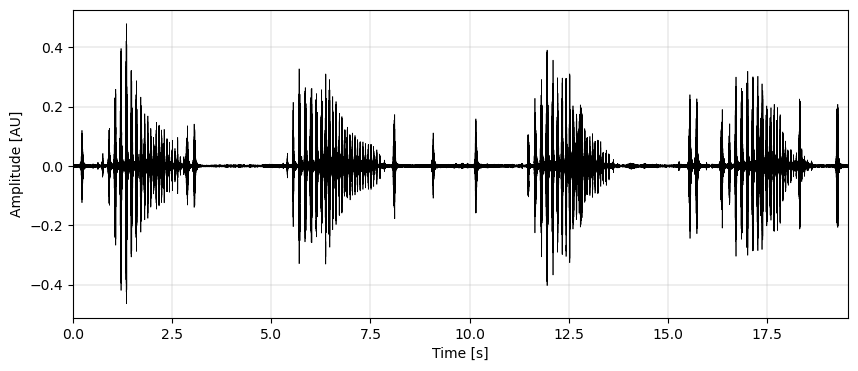

<Axes: xlabel='Time [s]', ylabel='Amplitude [AU]'>

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from maad.util import plot1d

def plot_wave(s, fs, tlims=None, ax=None, **kwargs):
    """
    Plot audio waveform.
    
    Parameters
    ----------
    s : 1d ndarray
        Audio signal.
    fs : int
        Sampling rate of audio signal.
    tlims : tuple, optional
        Minimum and maximum temporal limits for the display (min_t, max_t). 
        The default is None.
    ax : matplotlib.axes, optional
        Pre-existing axes for the plot. The default is None.
    **kwargs : matplotlib figure properties
        Other keyword arguments that are passed down to matplotlib.axes.

    Returns
    -------
    ax : matplotlib.axes
        The matplotlib axes associated to plot.
    
    See also
    --------
    maad.sound.plot_spectrum
        
    Examples
    --------
    
    Plot a waveform of an audio signal.
    >>> from maad import sound
    >>> from maad.util import plot_wave
    >>> s, fs = sound.load('../data/spinetail.wav')
    >>> ax = plot_wave(s, fs)
    
    Use `plot_wave` with predifined matplotlib axes.
    >>> import matplotlib.pyplot as plt
    >>> s, fs = sound.load('../data/spinetail.wav')
    >>> fig, ax = plt.subplots(2,1)
    >>> plot_wave(s, fs, ax=ax[0], xlabel='', figtitle='Spinetail')
    >>> plot_wave(s, fs, tlims=(5,8), ax=ax[1])
    """

    if tlims is not None:
        s = s[int(tlims[0] * fs) : int(tlims[1] * fs)]
        t = np.linspace(0, s.shape[0] / fs, s.shape[0])
        t = t + tlims[0]  # add minimum value
    else:
        t = np.linspace(0, s.shape[0] / fs, s.shape[0])

    ax, fig = plot1d(t, s, ax, **kwargs)

    plt.show()
    plt.close(fig)

    return ax

s, fs = sound.load('./data/spinetail.wav')
plot_wave(s, fs)

In [31]:
def plot1d(x, y, ax=None, show=True, **kwargs):
    """
    Plot the waveform or spectrum of an audio signal. 
    
    Parameters
    ----------
    x : 1d ndarray of integer
        Vector containing the abscissa values (horizontal axis)
        
    y : 1d ndarray of scalar
        Vector containing the ordinate values (vertical axis)  
    
    ax : axis, optional, default is None
        Draw the signal on this specific axis. Allow multiple plots on the same
        axis.
            
    kwargs, optional
        - figsize : tuple of integers, optional, default: (4,10)
            width, height in inches.  
        - facecolor : matplotlib color, optional, default: 'w' (white)
            the background color.  
        - edgecolor : matplotlib color, optional, default: 'k' (black)
            the border color. 
        - color : matplotlib color, optional, default: 'k' (black)
            the line color
            The following color abbreviations are supported:
            ==========  ========
            character   color
            ==========  ========
            'b'         blue
            'g'         green
            'r'         red
            'c'         cyan
            'm'         magenta
            'y'         yellow
            'k'         black
            'w'         white
            ==========  ========
            In addition, you can specify colors in many ways, including RGB 
            tuples (0.2,1,0.5). See matplotlib color
        - linewidth : scalar, optional, default: 0.5
            width in pixels
        - figtitle: string, optional, default: 'Audiogram'
            Title of the plot 
        - xlabel : string, optional, default : 'Time [s]'
            label of the horizontal axis
        - ylabel : string, optional, default : 'Amplitude [AU]'
            label of the vertical axis
        - legend : string, optional, default : None
            Legend for the plot
        - now : boolean, optional, default : True
            if True, display now. Cannot display multiple plots. 
            To display mutliple plots, set now=False until the last call for 
            the last plot         
        
        ...and more, see matplotlib
        
    Returns
    -------
    fig : Figure
        The Figure instance 
    ax : Axis
        The Axis instance
        
    Examples
    --------
    >>> import numpy as np    
    >>> s, fs = maad.sound.load('../data/cold_forest_daylight.wav') 
    
    Plot the audiogram
    
    >>> tn = np.arange(0,len(s))/fs
    >>> fig, ax = maad.util.plot1d(tn,s)
    
    >>> Sxx_power,tn,fn,_ = maad.sound.spectrogram(s,fs)
    
    Convert spectrogram into dB SPL
    
    >>> Lxx = maad.spl.power2dBSPL(Sxx_power, gain=42) 
    
    Plot the spectrum at t = 7s
    
    >>> index = maad.util.nearest_idx(tn,7)
    >>> fig_kwargs = {'figtitle':'Spectrum (PSD)',
                    'xlabel':'Frequency [Hz]',
                    'ylabel':'Power [dB]',
                    'linewidth': 0.5
                    }
    
    >>> fig, ax = maad.util.plot1d(fn, Lxx[:,index], **fig_kwargs)
    """

    figsize = kwargs.pop("figsize", (4, 10))
    facecolor = kwargs.pop("facecolor", "w")
    edgecolor = kwargs.pop("edgecolor", "k")
    linewidth = kwargs.pop("linewidth", 0.5)
    color = kwargs.pop("color", "k")
    title = kwargs.pop("figtitle", "")
    xlabel = kwargs.pop("xlabel", "Time [s]")
    ylabel = kwargs.pop("ylabel", "Amplitude [AU]")
    legend = kwargs.pop("legend", None)
    now = kwargs.pop("now", False)

    # if no ax, create a figure and a subplot associated a figure otherwise
    # find the figure that belongs to ax
    if ax is None:
        fig, ax = plt.subplots()
        # set the paramters of the figure
        fig.set_figheight(figsize[0])
        fig.set_figwidth(figsize[1])
        fig.set_facecolor(facecolor)
        fig.set_edgecolor(edgecolor)
    else:
        fig = ax.get_figure()

    # plot the data on the subplot
    line = ax.plot(x, y, color=color, linewidth=linewidth, **kwargs)

    # set legend to the line
    line[0].set_label(legend)

    # set the parameters of the subplot
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    #ax.axis("tight")
    ax.grid(True, linewidth=0.3)
    ax.margins(x=0)
    
    if legend is not None:
        ax.legend()

    # Display the figure now
    if now:
        plt.show()

    if not show:
        plt.close(fig)
    return ax, fig


import numpy as np    
s, fs = sound.load('./data/cold_forest_daylight.wav') 

# Plot the audiogram

tn = np.arange(0,len(s))/fs
fig, ax = plot1d(tn,s, show=False)

Sxx_power,tn,fn,_ = sound.spectrogram(s,fs)

# Convert spectrogram into dB SPL

Lxx = spl.power2dBSPL(Sxx_power, gain=42) 

# Plot the spectrum at t = 7s

index = util.nearest_idx(tn,7)
fig_kwargs = {'figtitle':'Spectrum (PSD)',
                'xlabel':'Frequency [Hz]',
                'ylabel':'Power [dB]',
                'linewidth': 0.5
                }

fig, ax = plot1d(fn, Lxx[:,index], show=False, **fig_kwargs)